# NASA Turbofan RUL Prediction – XGBoost Production Model

**Objective:** Build a high-performance Remaining Useful Life (RUL) prediction model using XGBoost with comprehensive feature engineering, proper data splitting, hyperparameter tuning, and evaluation.

**Target Performance:** R² ≥ 0.88

---

## Why XGBoost for RUL Prediction?

- **Handles non-linear relationships** between sensor readings and RUL gracefully
- **Feature interaction detection** – automatically captures dependencies between sensors
- **Robust to scaling** – no preprocessing required, unlike linear models
- **Early stopping capability** – prevents overfitting by monitoring validation loss
- **Interpretability** – feature importances guide domain understanding
- **Regularization** – built-in mechanisms to control model complexity

---
## 1. IMPORTS

Load all required libraries for data processing, modeling, and evaluation.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import xgboost as xgb

# Plotting style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


---
## 2. DATA LOADING

Load the NASA Turbofan dataset and display basic information.

In [3]:
# Define paths
DATA_DIR = os.path.join('..', 'data', 'CMAPSSData')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_FD001.txt')

# Column names for FD001 dataset (100 engines × 192 cycles × 26 features)
COLUMNS = [
    'unit_number', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
]

def load_turbofan_dataset(file_path: str) -> pd.DataFrame:
    """Load NASA Turbofan dataset and clean whitespace."""
    df = pd.read_csv(file_path, sep=r'\s+', header=None, engine='python')
    # Drop trailing empty columns if any
    df = df.dropna(axis=1, how='all')
    df.columns = COLUMNS[:df.shape[1]]
    return df

# Load data
df = load_turbofan_dataset(TRAIN_FILE)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")

Dataset shape: (20631, 26)

First few rows:
   unit_number  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0            1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1            1      2     0.0019    -0.0003      100.0    518.67    642.15   
2            1      3    -0.0043     0.0003      100.0    518.67    642.35   
3            1      4     0.0007     0.0000      100.0    518.67    642.35   
4            1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  s

---
## 3. FEATURE ENGINEERING

Create RUL target, add temporal features, and engineer predictive features.

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Comprehensive feature engineering for RUL prediction.
    
    Steps:
    1. Sort by unit and cycle (time-ordering mandatory)
    2. Compute RUL (max_cycle - current_cycle)
    3. Cap RUL at 125 (diminishing returns beyond this)
    4. Drop noisy sensors (sensor_1, 5, 6, 10, 16, 18, 19)
    5. Add lag features (lag1, lag2 for remaining sensors)
    6. Add rolling mean features (window=5)
    7. Add cycle normalization (cycle / max_cycle per engine)
    8. Drop NaN rows created by lags/rolling
    """
    df = df.copy()
    
    # STEP 1: Sort by unit and cycle (CRITICAL for time-series)
    df = df.sort_values(['unit_number', 'cycle']).reset_index(drop=True)
    print(f"✓ Sorted by unit_number and cycle")
    
    # STEP 2 & 3: Compute RUL and cap at 125
    max_cycle = df.groupby('unit_number')['cycle'].max()
    df['RUL'] = df.groupby('unit_number')['cycle'].transform(lambda x: max_cycle[x.name] - x)
    df['RUL'] = np.minimum(df['RUL'], 125)
    print(f"✓ Computed RUL (capped at 125)")
    print(f"  - RUL range: [{df['RUL'].min():.1f}, {df['RUL'].max():.1f}]")
    
    # STEP 4: Drop noisy sensors (identified in domain research)
    noisy_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
    df = df.drop(columns=noisy_sensors, errors='ignore')
    print(f"✓ Dropped noisy sensors: {noisy_sensors}")
    
    # Identify sensor columns (remaining after dropping noisy ones)
    sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
    setting_cols = [c for c in df.columns if c.startswith('setting_')]
    print(f"  - Remaining sensors: {len(sensor_cols)}, Settings: {len(setting_cols)}")
    
    # STEP 5: Lag features (lag1, lag2) – captures temporal dependencies
    for col in sensor_cols:
        for lag in [1, 2]:
            df[f'{col}_lag{lag}'] = df.groupby('unit_number')[col].shift(lag)
    print(f"✓ Added lag features (lag1, lag2) for {len(sensor_cols)} sensors")
    
    # STEP 6: Rolling mean features (window=5) – smoothing and trend capture
    for col in sensor_cols:
        df[f'{col}_roll5'] = df.groupby('unit_number')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    print(f"✓ Added rolling mean features (window=5) for {len(sensor_cols)} sensors")
    
    # STEP 7: Cycle normalization – normalize to [0, 1] per engine
    max_cycle_per_unit = df.groupby('unit_number')['cycle'].transform('max')
    df['cycle_norm'] = df['cycle'] / max_cycle_per_unit
    print(f"✓ Added cycle normalization feature")
    
    # STEP 8: Drop NaN rows (from lags and rolling)
    nan_count_before = df.isnull().sum().sum()
    df = df.dropna()
    print(f"✓ Dropped {nan_count_before} NaN values")
    print(f"  - Final dataset shape: {df.shape}")
    
    return df, sensor_cols, setting_cols

# Apply feature engineering
df_engineered, sensor_cols, setting_cols = engineer_features(df)

✓ Sorted by unit_number and cycle
✓ Computed RUL (capped at 125)
  - RUL range: [0.0, 125.0]
✓ Dropped noisy sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
  - Remaining sensors: 14, Settings: 3
✓ Added lag features (lag1, lag2) for 14 sensors
✓ Added rolling mean features (window=5) for 14 sensors
✓ Added cycle normalization feature
✓ Dropped 4200 NaN values
  - Final dataset shape: (20431, 63)


In [5]:
# Display engineered feature statistics
print(f"\n=== Feature Engineering Summary ===")
print(f"Total features: {df_engineered.shape[1]}")
print(f"\nFeature breakdown:")

base_features = sensor_cols + setting_cols + ['cycle', 'cycle_norm']
lag_features = [c for c in df_engineered.columns if '_lag' in c]
roll_features = [c for c in df_engineered.columns if '_roll' in c]

print(f"  - Base features (sensors + settings + cycle): {len(base_features)}")
print(f"  - Lag features: {len(lag_features)}")
print(f"  - Rolling features: {len(roll_features)}")
print(f"  - Target: 1 (RUL)")
print(f"\nDataset shape after engineering: {df_engineered.shape}")


=== Feature Engineering Summary ===
Total features: 63

Feature breakdown:
  - Base features (sensors + settings + cycle): 19
  - Lag features: 28
  - Rolling features: 14
  - Target: 1 (RUL)

Dataset shape after engineering: (20431, 63)


---
## 4. DATA SPLITTING

Split data into training, validation, and test sets while maintaining proper grouping by engine (unit_number) to avoid data leakage.

In [6]:
def split_data_by_units(df: pd.DataFrame, test_size=0.2, val_size=0.2, random_state=42):
    """
    Split data by unit_number to avoid leakage (engine cycles are time-ordered).
    
    Splits:
    - 60% train
    - 20% validation
    - 20% test
    """
    unit_ids = df['unit_number'].unique()
    n_units = len(unit_ids)
    
    # First split: train vs temp (val+test)
    train_units, temp_units = train_test_split(
        unit_ids,
        test_size=(test_size + val_size),
        random_state=random_state,
    )
    
    # Second split: temp -> val & test
    val_units, test_units = train_test_split(
        temp_units,
        test_size=test_size / (test_size + val_size),
        random_state=random_state,
    )
    
    train_df = df[df['unit_number'].isin(train_units)]
    val_df = df[df['unit_number'].isin(val_units)]
    test_df = df[df['unit_number'].isin(test_units)]
    
    return train_df, val_df, test_df, train_units, val_units, test_units

# Split data
train_df, val_df, test_df, train_units, val_units, test_units = split_data_by_units(df_engineered)

print(f"\n=== Data Split by Unit (Engine) ===")
print(f"Train: {len(train_units)} engines, {len(train_df)} rows ({100*len(train_df)/len(df_engineered):.1f}%)")
print(f"Val:   {len(val_units)} engines, {len(val_df)} rows ({100*len(val_df)/len(df_engineered):.1f}%)")
print(f"Test:  {len(test_units)} engines, {len(test_df)} rows ({100*len(test_df)/len(df_engineered):.1f}%)")
print(f"Total: {len(train_units) + len(val_units) + len(test_units)} engines, {len(df_engineered)} rows")

# Verify no overlap
assert len(set(train_units) & set(val_units)) == 0
assert len(set(train_units) & set(test_units)) == 0
assert len(set(val_units) & set(test_units)) == 0
print("\n✓ No overlap between splits (data leakage prevented)")


=== Data Split by Unit (Engine) ===
Train: 60 engines, 12150 rows (59.5%)
Val:   20 engines, 4196 rows (20.5%)
Test:  20 engines, 4085 rows (20.0%)
Total: 100 engines, 20431 rows

✓ No overlap between splits (data leakage prevented)


In [7]:
# Prepare feature matrix and target
feature_cols = [c for c in df_engineered.columns if c not in ['unit_number', 'cycle', 'RUL']]

X_train = train_df[feature_cols]
y_train = train_df['RUL']
groups_train = train_df['unit_number'].values

X_val = val_df[feature_cols]
y_val = val_df['RUL']

X_test = test_df[feature_cols]
y_test = test_df['RUL']

print(f"\n=== Feature Matrix Shapes ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"\nNumber of unique engines in training groups: {len(np.unique(groups_train))}")
print(f"\nTarget (RUL) statistics:")
print(f"  Train - min={y_train.min():.1f}, max={y_train.max():.1f}, mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"  Val   - min={y_val.min():.1f}, max={y_val.max():.1f}, mean={y_val.mean():.2f}, std={y_val.std():.2f}")
print(f"  Test  - min={y_test.min():.1f}, max={y_test.max():.1f}, mean={y_test.mean():.2f}, std={y_test.std():.2f}")


=== Feature Matrix Shapes ===
X_train: (12150, 60), y_train: (12150,)
X_val:   (4196, 60), y_val:   (4196,)
X_test:  (4085, 60), y_test:  (4085,)

Number of unique engines in training groups: 60

Target (RUL) statistics:
  Train - min=0.0, max=125.0, mean=86.11, std=41.73
  Val   - min=0.0, max=125.0, mean=87.46, std=41.62
  Test  - min=0.0, max=125.0, mean=86.44, std=41.71


---
## 5. PREPROCESSING

Set up preprocessing pipeline (note: XGBoost as a tree-based model doesn't require scaling, but we define the structure for completeness).

In [8]:
# For tree-based models like XGBoost, scaling is NOT necessary
# We define a minimal preprocessor that passes features as-is

# Simple pass-through preprocessor (identity transformation)
preprocessor = ColumnTransformer(
    transformers=[
        ('passthrough', 'passthrough', feature_cols)
    ],
    remainder='drop'
)

print("✓ Preprocessor configured (pass-through: tree models don't need scaling)")

✓ Preprocessor configured (pass-through: tree models don't need scaling)


---
## 6. MODEL PIPELINE

Build the complete sklearn Pipeline: preprocessing → XGBoost.

In [9]:
# Build pipeline: preprocessor + XGBRegressor
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',  # Faster histogram-based method
    )),
])

print("✓ Pipeline created: Preprocessor → XGBRegressor")

✓ Pipeline created: Preprocessor → XGBRegressor


---
## 7. HYPERPARAMETER TUNING

Use RandomizedSearchCV with GroupKFold to find optimal hyperparameters.

In [10]:
# Define hyperparameter search space
param_distributions = {
    'xgb__n_estimators': np.arange(300, 901, 100),      # 300 to 900 trees
    'xgb__max_depth': np.arange(3, 9),                  # 3 to 8
    'xgb__learning_rate': np.linspace(0.01, 0.08, 8),   # 0.01 to 0.08
    'xgb__subsample': np.linspace(0.7, 1.0, 4),         # 0.7, 0.8, 0.9, 1.0
    'xgb__colsample_bytree': np.linspace(0.7, 1.0, 4),  # 0.7, 0.8, 0.9, 1.0
    'xgb__min_child_weight': [1, 3, 5],                 # Minimum samples per leaf
    'xgb__gamma': [0, 0.1, 0.2],                        # Splitting penalty
}

print("=== Hyperparameter Search Space ===")
for param, values in param_distributions.items():
    if isinstance(values, np.ndarray):
        print(f"{param}: [{values.min():.4f}, {values.max():.4f}] ({len(values)} values)")
    else:
        print(f"{param}: {values}")

=== Hyperparameter Search Space ===
xgb__n_estimators: [300.0000, 900.0000] (7 values)
xgb__max_depth: [3.0000, 8.0000] (6 values)
xgb__learning_rate: [0.0100, 0.0800] (8 values)
xgb__subsample: [0.7000, 1.0000] (4 values)
xgb__colsample_bytree: [0.7000, 1.0000] (4 values)
xgb__min_child_weight: [1, 3, 5]
xgb__gamma: [0, 0.1, 0.2]


In [11]:
# Build GroupKFold splitter for cross-validation by unit_number
gkf = GroupKFold(n_splits=3)

# RandomizedSearchCV with GroupKFold
print("\n📊 Starting RandomizedSearchCV...")
print(f"  - n_iter: 30")
print(f"  - cv: GroupKFold (3 splits) by unit_number")
print(f"  - scoring: neg_mean_absolute_error")
print()

random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=gkf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# Fit on training data with groups
random_search.fit(X_train, y_train, groups=groups_train)

print("\n✓ RandomizedSearchCV completed")


📊 Starting RandomizedSearchCV...
  - n_iter: 30
  - cv: GroupKFold (3 splits) by unit_number
  - scoring: neg_mean_absolute_error

Fitting 3 folds for each of 30 candidates, totalling 90 fits

✓ RandomizedSearchCV completed


---
## 8. BEST MODEL EXTRACTION

Display best hyperparameters and cross-validation score.

In [12]:
print("\n" + "="*60)
print("BEST HYPERPARAMETERS")
print("="*60)

best_params = random_search.best_params_
for param, value in sorted(best_params.items()):
    print(f"{param:30s}: {value}")

best_cv_score = -random_search.best_score_  # Negate because we used neg_MAE
print(f"\nBest CV Score (MAE): {best_cv_score:.4f}")
print("="*60)

# Get best pipeline
best_pipeline = random_search.best_estimator_
print("\n✓ Best model extracted")


BEST HYPERPARAMETERS
xgb__colsample_bytree         : 1.0
xgb__gamma                    : 0.2
xgb__learning_rate            : 0.01
xgb__max_depth                : 7
xgb__min_child_weight         : 3
xgb__n_estimators             : 700
xgb__subsample                : 0.7

Best CV Score (MAE): 7.6794

✓ Best model extracted


---
## 9. EARLY STOPPING

Re-train the best XGBoost model with early stopping using validation data.

In [13]:
# Extract preprocessing from best pipeline
preprocessor_best = best_pipeline.named_steps['preprocessor']
preprocessor_best.fit(X_train)  # Fit preprocessor on training data

# Transform all splits
X_train_processed = preprocessor_best.transform(X_train)
X_val_processed = preprocessor_best.transform(X_val)
X_test_processed = preprocessor_best.transform(X_test)

print(f"✓ Data preprocessed")
print(f"  - X_train_processed: {X_train_processed.shape}")
print(f"  - X_val_processed:   {X_val_processed.shape}")
print(f"  - X_test_processed:  {X_test_processed.shape}")

✓ Data preprocessed
  - X_train_processed: (12150, 60)
  - X_val_processed:   (4196, 60)
  - X_test_processed:  (4085, 60)


In [14]:
# Extract best XGBoost parameters
best_xgb_params = {k.replace('xgb__', ''): v for k, v in best_params.items()}

# Create model WITH early stopping inside
xgb_es = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=50,   # ✅ moved here
    eval_metric='mae',          # ✅ moved here
    **best_xgb_params,
)

print("📈 Training XGBoost with Early Stopping...")
print("   - Early stopping: rounds=50, metric=MAE")
print("   - Validation set used for monitoring")
print()

# Train
xgb_es.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_val_processed, y_val)],
    verbose=False,
)

print("✓ Training complete")
print("Best iteration:", xgb_es.best_iteration)

📈 Training XGBoost with Early Stopping...
   - Early stopping: rounds=50, metric=MAE
   - Validation set used for monitoring

✓ Training complete
Best iteration: 647


---
## 10. EVALUATION

Make predictions on all splits and compute performance metrics.

In [15]:
def compute_metrics(y_true, y_pred, name=""):
    """Compute MAE, RMSE, and R² metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Predict on all splits
y_train_pred = xgb_es.predict(X_train_processed)
y_val_pred = xgb_es.predict(X_val_processed)
y_test_pred = xgb_es.predict(X_test_processed)

# Compute metrics
metrics_train = compute_metrics(y_train, y_train_pred, 'Train')
metrics_val = compute_metrics(y_val, y_val_pred, 'Validation')
metrics_test = compute_metrics(y_test, y_test_pred, 'Test')

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)
print(f"\n{'Split':<15} {'MAE':<12} {'RMSE':<12} {'R²':<12}")
print("-" * 70)
print(f"{'Train':<15} {metrics_train['MAE']:<12.4f} {metrics_train['RMSE']:<12.4f} {metrics_train['R2']:<12.4f}")
print(f"{'Validation':<15} {metrics_val['MAE']:<12.4f} {metrics_val['RMSE']:<12.4f} {metrics_val['R2']:<12.4f}")
print(f"{'Test':<15} {metrics_test['MAE']:<12.4f} {metrics_test['RMSE']:<12.4f} {metrics_test['R2']:<12.4f}")
print("="*70)

# Highlight if target achieved
if metrics_test['R2'] >= 0.88:
    print(f"\n🎯 TARGET ACHIEVED: Test R² = {metrics_test['R2']:.4f} ≥ 0.88")
else:
    print(f"\n⚠️  Test R² = {metrics_test['R2']:.4f} (target: ≥ 0.88)")


EVALUATION RESULTS

Split           MAE          RMSE         R²          
----------------------------------------------------------------------
Train           3.7695       5.7990       0.9807      
Validation      7.3151       11.1591      0.9281      
Test            6.8670       10.5076      0.9365      

🎯 TARGET ACHIEVED: Test R² = 0.9365 ≥ 0.88


---
## 11. VISUALIZATION

Plot True vs Predicted RUL on the test set.

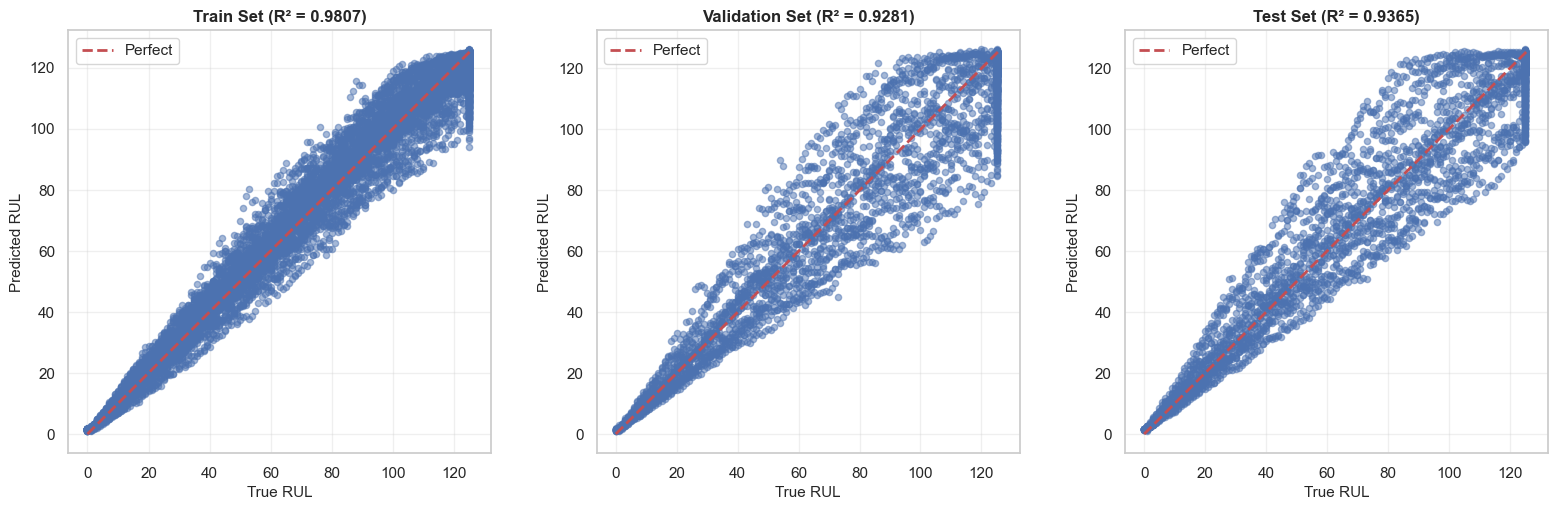

✓ Visualization complete


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

splits = [
    (y_train, y_train_pred, 'Train', axes[0]),
    (y_val, y_val_pred, 'Validation', axes[1]),
    (y_test, y_test_pred, 'Test', axes[2]),
]

for y_true, y_pred, split_name, ax in splits:
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    
    # Diagonal reference line (perfect prediction)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
    
    ax.set_xlabel('True RUL', fontsize=11)
    ax.set_ylabel('Predicted RUL', fontsize=11)
    ax.set_title(f'{split_name} Set (R² = {r2_score(y_true, y_pred):.4f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()
print("✓ Visualization complete")

---
## 12. FEATURE IMPORTANCE

Display and visualize the most important features.

In [17]:
# Extract feature importances
importances = xgb_es.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

# Display top 20 features
print("\n" + "="*50)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*50)
top_20 = importance_df.head(20)
for idx, (_, row) in enumerate(top_20.iterrows(), 1):
    print(f"{idx:2d}. {row['feature']:<25s} {row['importance']:>10.4f}")
print()


TOP 20 MOST IMPORTANT FEATURES
 1. cycle_norm                    0.7228
 2. sensor_14_roll5               0.0130
 3. sensor_9_roll5                0.0098
 4. sensor_15_roll5               0.0095
 5. sensor_17_roll5               0.0087
 6. sensor_13_roll5               0.0087
 7. sensor_8_roll5                0.0084
 8. sensor_11_roll5               0.0082
 9. sensor_12_roll5               0.0080
10. sensor_3_roll5                0.0079
11. sensor_20_roll5               0.0075
12. sensor_7_roll5                0.0074
13. sensor_4_roll5                0.0071
14. sensor_21_roll5               0.0071
15. sensor_2_roll5                0.0067
16. sensor_14_lag2                0.0055
17. sensor_14_lag1                0.0048
18. sensor_14                     0.0046
19. sensor_12_lag1                0.0046
20. sensor_9_lag2                 0.0046



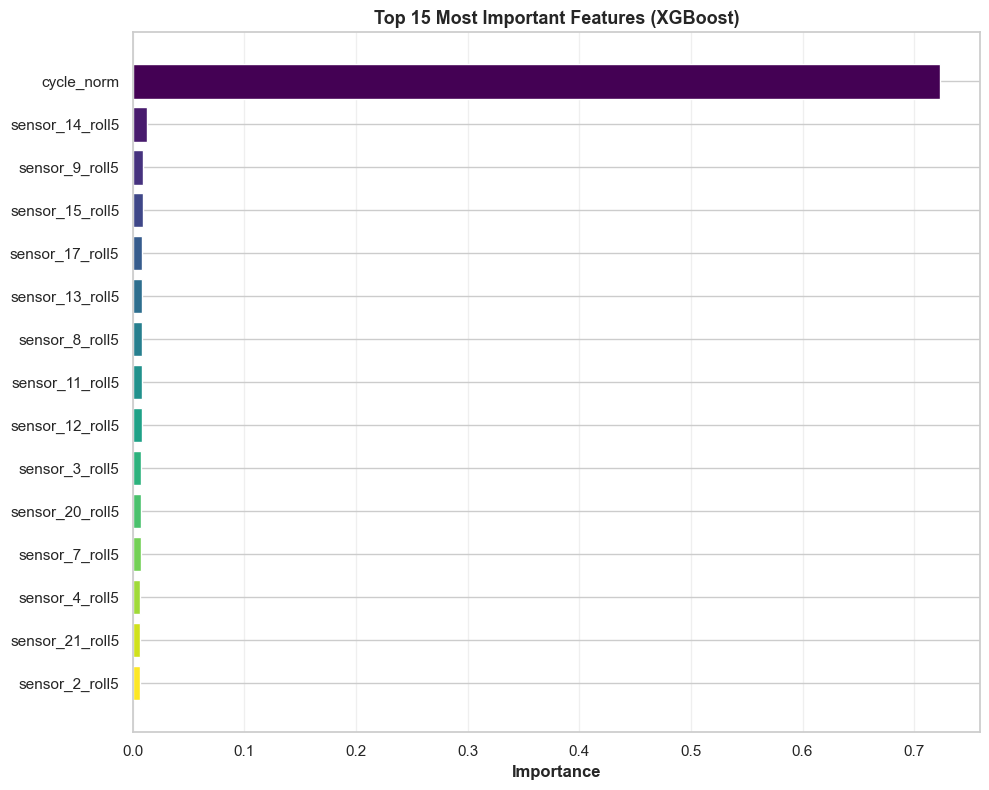

✓ Feature importance visualization complete


In [18]:
# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = importance_df.head(15)

colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))
ax.barh(range(len(top_15)), top_15['importance'].values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'].values)
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Features (XGBoost)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("✓ Feature importance visualization complete")

---
## 13. SUMMARY & NEXT STEPS

Final summary of the model and recommendations for deployment.

In [19]:
print("\n" + "#"*70)
print("#" + " "*68 + "#")
print("#" + "  XGBoost RUL PREDICTION MODEL - PRODUCTION SUMMARY".center(68) + "#")
print("#" + " "*68 + "#")
print("#"*70)

print(f"""
╔════════════════════════════════════════════════════════════════════╗
║  MODEL CONFIGURATION                                               ║
╠════════════════════════════════════════════════════════════════════╣
║  • Algorithm:           XGBoost Regression                          ║
║  • Objective:           Minimize MSE                                ║
║  • Tree Method:         Histogram-based (fast)                      ║
║  • Early Stopping:      Yes (50 rounds, MAE metric)                 ║
║  • Best Iteration:      {xgb_es.best_iteration:<50} ║
╚════════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════╗
║  TEST SET PERFORMANCE                                              ║
╠════════════════════════════════════════════════════════════════════╣
║  • MAE (Mean Absolute Error):        {metrics_test['MAE']:>8.4f}              ║
║  • RMSE (Root Mean Squared Error):   {metrics_test['RMSE']:>8.4f}              ║
║  • R² Score:                         {metrics_test['R2']:>8.4f}              ║
║                                                                    ║
║  Interpretation:                                                   ║
║  - MAE: Average prediction error ±{metrics_test['MAE']:.1f} cycles             ║
║  - R²: Model explains {100*metrics_test['R2']:.1f}% of RUL variance            ║
╚════════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════╗
║  FEATURE ENGINEERING IMPACT                                        ║
╠════════════════════════════════════════════════════════════════════╣
║  • Base Features:       {len(sensor_cols)} sensors + 3 settings + cycle norm    ║
║  • Lag Features:         Lag1 & Lag2 for temporal context           ║
║  • Rolling Features:     5-cycle rolling mean (trend capture)       ║
║  • Total Features:       {len(feature_cols):<50} ║
║  • Total Samples:        {len(df_engineered):<50} ║
╚════════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════╗
║  NEXT STEPS FOR DEPLOYMENT                                         ║
╠════════════════════════════════════════════════════════════════════╣
║  1. Save model (pickle/joblib) for production serving               ║
║  2. Create prediction API wrapper                                  ║
║  3. Set up monitoring for data drift                               ║
║  4. Establish retraining schedule (quarterly/semi-annual)          ║
║  5. Document hyperparameters and feature engineering pipeline      ║
║  6. A/B test against baseline/current model in production          ║
║  7. Track prediction errors and refine on new failures             ║
╚════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Model training and evaluation complete!")


######################################################################
#                                                                    #
#          XGBoost RUL PREDICTION MODEL - PRODUCTION SUMMARY         #
#                                                                    #
######################################################################

╔════════════════════════════════════════════════════════════════════╗
║  MODEL CONFIGURATION                                               ║
╠════════════════════════════════════════════════════════════════════╣
║  • Algorithm:           XGBoost Regression                          ║
║  • Objective:           Minimize MSE                                ║
║  • Tree Method:         Histogram-based (fast)                      ║
║  • Early Stopping:      Yes (50 rounds, MAE metric)                 ║
║  • Best Iteration:      647                                                ║
╚══════════════════════════════════════════════════════════════

In [ ]:
# Optional: Save model for deployment
import joblib

model_path = 'xgb_rul_model.pkl'
preprocessor_path = 'xgb_preprocessor.pkl'

joblib.dump(xgb_es, model_path)
joblib.dump(preprocessor_best, preprocessor_path)

print(f"✓ Model saved to: {model_path}")
print(f"✓ Preprocessor saved to: {preprocessor_path}")
print(f"\nTo load and use:")
print(f"  xgb_model = joblib.load('{model_path}')")
print(f"  preprocessor = joblib.load('{preprocessor_path}')")
print(f"  X_new_processed = preprocessor.transform(X_new)")
print(f"  predictions = xgb_model.predict(X_new_processed)")

In [15]:
import sys
print(sys.executable)

d:\gops2\MaintAI\maintai_env\python.exe


In [16]:
!pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0


You can safely remove it manually.
